# # Lyrical Data Exploration
# An deep-dive into the thematic, temporal, and popularity metrics of our analyzed band.

In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from wordcloud import WordCloud
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer

# Configure plotting aesthetics
sns.set_theme(style="darkgrid", context="notebook")
plt.rcParams['figure.figsize'] = (12, 8)

# ### 1. Unified Dataset Construction
# We merge the NLP lemmas, API metadata, and mathematical topics into a single DataFrame.

In [4]:
def load_unified_data(band_name: str) -> pd.DataFrame:
    """Load and merge processed text, metadata, and analysis into one DataFrame."""
    base_dir = Path("../data")
    safe_band = band_name.replace(" ", "_").lower()
    
    # Load components
    df_text = pd.read_json(base_dir / f"processed/{safe_band}_processed.json")
    
    with open(base_dir / f"metadata/{safe_band}_meta.json", "r") as f:
        meta_dict = json.load(f)
    df_meta = pd.DataFrame.from_dict(meta_dict, orient="index").reset_index(names="song")
    
    with open(base_dir / f"export/{safe_band}_analysis.json", "r") as f:
        analysis = json.load(f)
    df_topics = pd.DataFrame(list(analysis["song_mapping"].items()), columns=["song", "topic_id"])
    
    # Merge and clean
    df = df_text.merge(df_meta, on="song").merge(df_topics, on="song")
    df["topic_name"] = df["topic_id"].apply(lambda x: f"Topic {x}")
    df["word_count"] = df["lemmas"].apply(lambda x: len(x.split()))
    return df, analysis["topics"]

band = "system_of_a_down"
df, topic_words = load_unified_data(band)
df.head()

,song,lemmas,year,pageviews,album,topic_id,topic_name,word_count
0,aerials,life waterfall river fall void hear word lose ...,2001,669117,Toxicity (Blue Edition),5,Topic 5,75
1,atwa,atwa stand animal ecologist mandate begin noto...,2001,350487,Toxicity (Blue Edition),0,Topic 0,94
2,b.y.o.b.,send poor barbarism pointed heel kneel brand n...,2005,815956,Mezmerize,10,Topic 10,174
3,bounce,jump bounce go date girl bit late friend glide...,2001,193167,Toxicity (Blue Edition),4,Topic 4,33
4,chic_‘n’_stu,refrigerator close light gettin hard splendid ...,2002,199137,Steal This Album!,7,Topic 7,217


# ### 2. Thematic Popularity (Swarm Plot)
# Do certain lyrical themes draw more pageviews than others? 

In [5]:
def plot_topic_popularity(df: pd.DataFrame) -> None:
    """Plot song popularity grouped by mathematical topic."""
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=df, x="topic_name", y="pageviews", color="lightgray", showfliers=False, ax=ax)
    sns.stripplot(data=df, x="topic_name", y="pageviews", hue="topic_name", size=8, jitter=True, legend=False, ax=ax)
    ax.set_title("Song Popularity (Pageviews) by Dominant Topic", fontsize=16)
    ax.set_yscale("log") # Log scale helps normalize massive hit songs
    ax.set_ylabel("Genius Pageviews (Log Scale)")
    plt.show()

# ### 3. Temporal Theme Shifts (Bubble Chart)
# Tracking how the band's focus shifted across release years. (Size = Popularity).

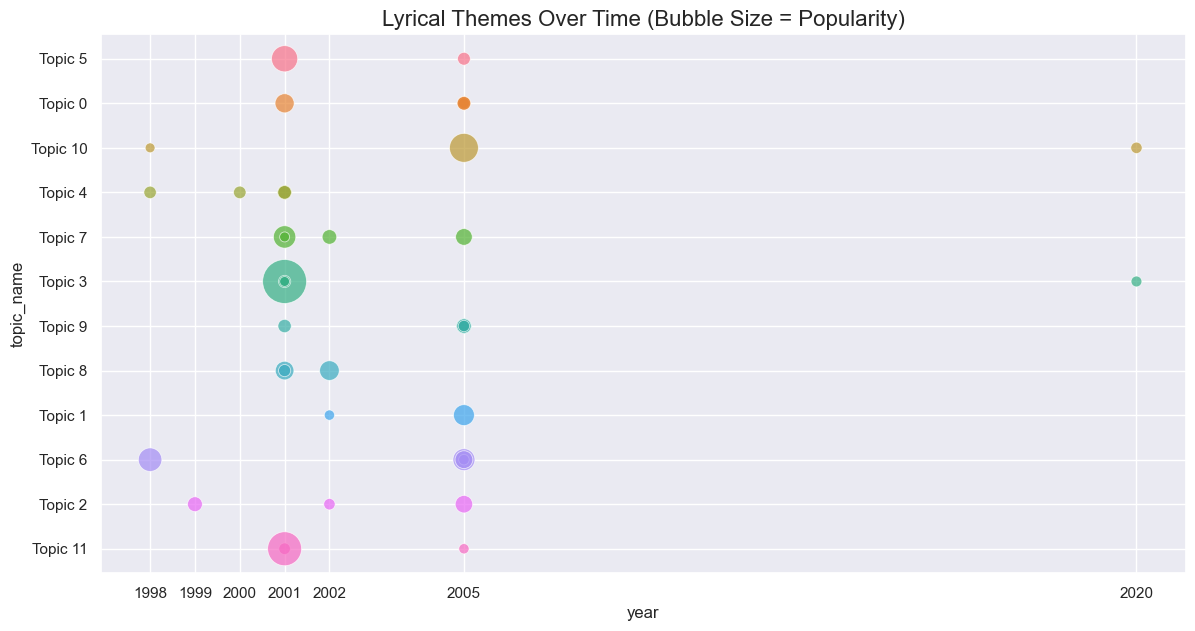

In [6]:
def plot_temporal_themes(df: pd.DataFrame) -> None:
    """Plot topic distribution over time, sizing points by pageviews."""
    df_time = df.dropna(subset=["year"]).copy()
    if df_time.empty:
        print("No year data available to plot.")
        return
        
    fig, ax = plt.subplots(figsize=(14, 7))
    sns.scatterplot(
        data=df_time, x="year", y="topic_name", hue="topic_name", 
        size="pageviews", sizes=(50, 1000), alpha=0.7, legend=False, ax=ax
    )
    ax.set_title("Lyrical Themes Over Time (Bubble Size = Popularity)", fontsize=16)
    ax.set_xticks(sorted(df_time["year"].unique()))
    plt.show()
    
plot_temporal_themes(df)

# ### 4. The Level-Up: Thematic Word Clouds
# Instead of one messy word cloud, we generate a distinct  cloud for each mathematical topic.

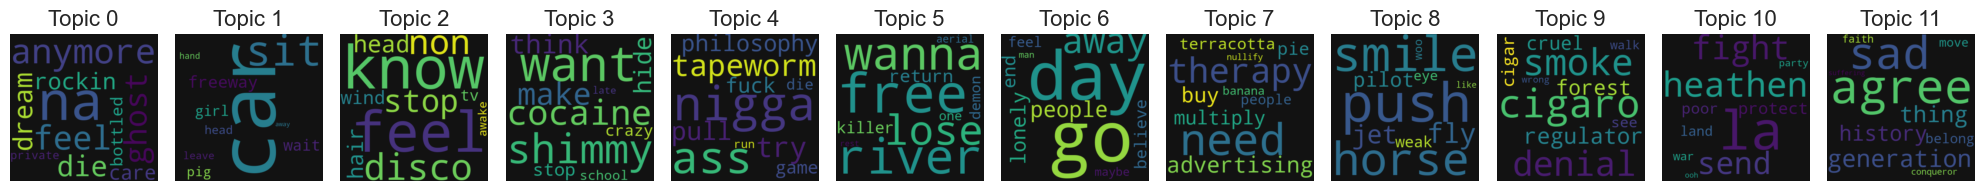

In [7]:
def plot_topic_wordclouds(topics: dict) -> None:
    """Generate and plot a grid of word clouds based on NMF topic weights."""
    num_topics = len(topics)
    fig, axes = plt.subplots(1, num_topics, figsize=(20, 5))
    
    for i, (topic_name, words) in enumerate(topics.items()):
        # Fake frequencies to give top words larger sizes in the cloud
        freq = {word: len(words) - j for j, word in enumerate(words)}
        wc = WordCloud(width=400, height=400, background_color="#121212", colormap="viridis")
        wc.generate_from_frequencies(freq)
        
        axes[i].imshow(wc, interpolation="bilinear")
        axes[i].set_title(topic_name.replace("_", " ").title(), fontsize=16)
        axes[i].axis("off")
        
    plt.tight_layout()
    plt.show()

plot_topic_wordclouds(topic_words)

# ### 5. 2D Semantic Song Map (PCA Clustering)
# We flatten the TF-IDF matrix into 2 dimensions. Songs that appear close together physically share similar lyrical vocabularies.


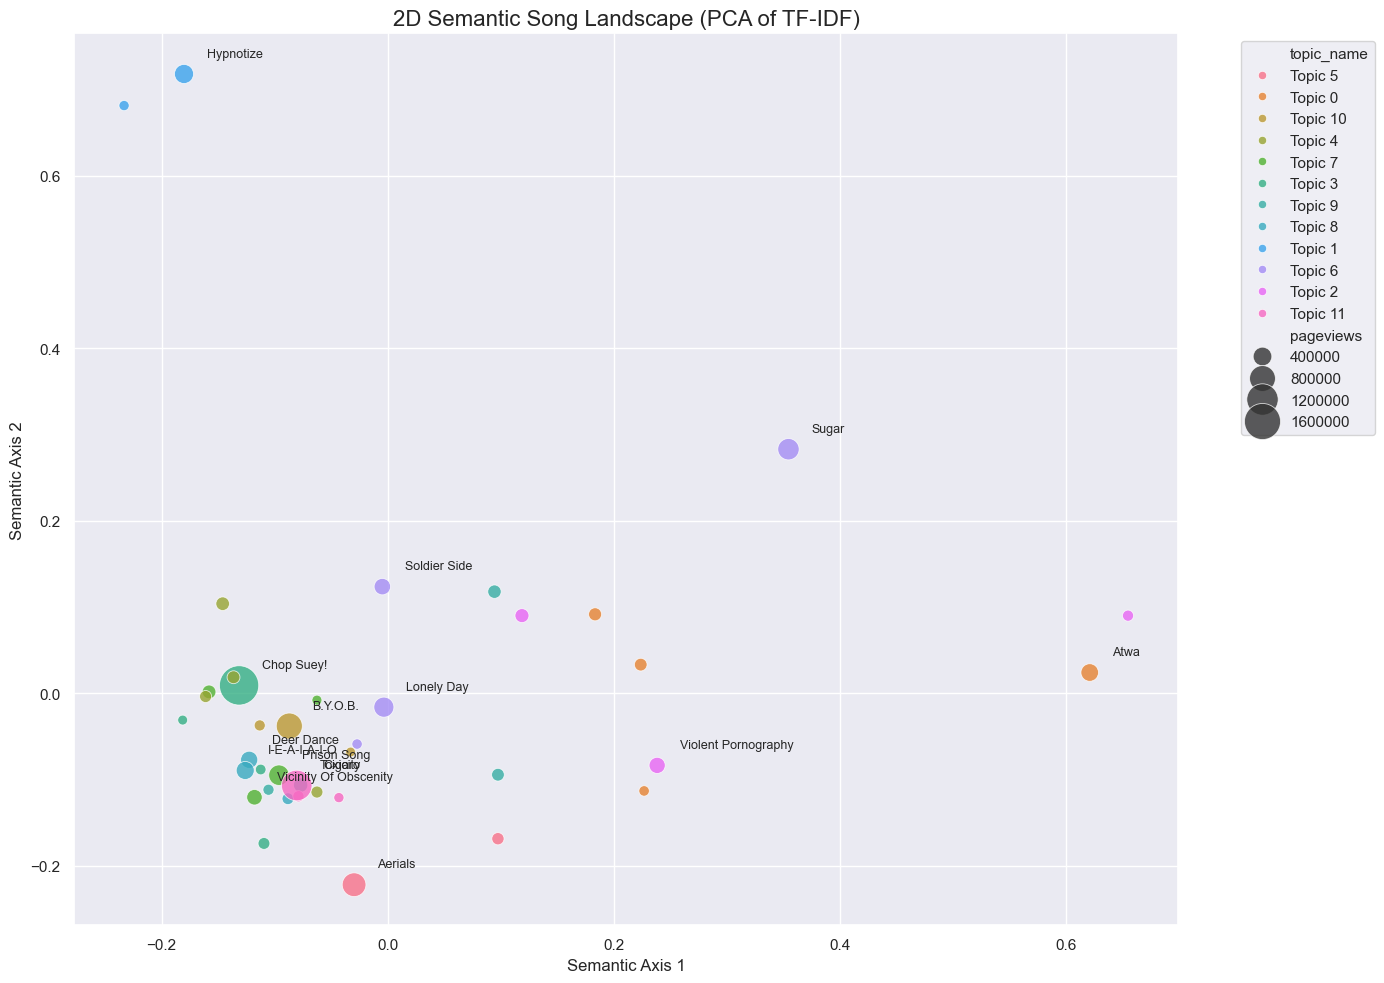

In [8]:
def plot_semantic_map(df: pd.DataFrame) -> None:
    """Perform PCA on song lemmas and plot the 2D semantic relationships."""
    # Re-vectorize to get math matrix
    vectorizer = TfidfVectorizer(max_features=500)
    matrix = vectorizer.fit_transform(df["lemmas"])
    
    # Flatten thousands of dimensions down to X and Y
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(matrix.toarray())
    
    df_pca = df.copy()
    df_pca["x"] = coords[:, 0]
    df_pca["y"] = coords[:, 1]
    
    fig, ax = plt.subplots(figsize=(14, 10))
    sns.scatterplot(
        data=df_pca, x="x", y="y", hue="topic_name", 
        size="pageviews", sizes=(50, 800), alpha=0.8, ax=ax
    )
    
    # Annotate the top 15 most popular songs
    top_songs = df_pca.nlargest(15, "pageviews")
    for _, row in top_songs.iterrows():
        ax.text(row["x"] + 0.02, row["y"] + 0.02, row["song"].replace("_", " ").title(), fontsize=9)

    ax.set_title("2D Semantic Song Landscape (PCA of TF-IDF)", fontsize=16)
    ax.set_xlabel("Semantic Axis 1")
    ax.set_ylabel("Semantic Axis 2")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

plot_semantic_map(df)